# **Tutorial: Deformable Image Registration Using Elastix**

---

Created by Dr Nicholas Senn, AMT Center, University of Aberdeen

Originally created for the Advanced Chest MRI School, Aberdeen, Septemeber 2026

Email: nicholas.senn2@abdn.ac.uk

Github page: https://github.com/nicholas-senn/teaching-resources/tree/main/lung-MRI/Advanced-Chest-MRI-School-2026/Image-Registration

The tutorial was developed as part of the V|LF-Spiro3D project: https://v-lf-spiro3d.eu/

-----------------------------------------------------------

This material is provided for educational and research purposes only.
It is not intended for clinical use.

© Nicholas Senn, 2026.
Released under the MIT Licence.

The software is provided "as is", without warranty of any kind.

-----------------------------------------------------------

## Introduction

Respiratory motion is a major challenge in MRI. Images acquired at different points in the breathing cycle may show substantial changes in the position and shape of anatomical structures, making direct comparison difficult. Image registration seeks to estimate this motion and align images acquired at different respiratory states.

Deformable image registration is widely used in medical imaging for motion correction, image reconstruction, longitudinal image analysis, radiation therapy planning and functional imaging. In lung imaging, deformation fields generated through registration can provide quantitative information about regional tissue motion and lung mechanics.

In this tutorial, we will use **Elastix**, an open-source image registration toolkit, to align two respiratory states of a digital breathing brain phantom. The phantom provides a controlled environment in which the underlying motion is known, allowing us to focus on understanding the registration process before moving to more complex datasets.

Throughout this tutorial, we will work through a complete registration workflow, from loading the data and performing registration through to visualising deformation fields and Jacobian determinant maps.

The primary objective of this tutorial is to provide example code needed to get started with Elastix. The Elastix GitHub page contains links to multiple notebook tutorials:

https://github.com/SuperElastix/elastix

## Learning Objectives

By the end of this tutorial, you should be able to:

- Understand the concepts of fixed and moving images.
- Perform rigid, affine and deformable image registration using Elastix.
- Understand the role of registration metrics and regularisation.
- Assess registration quality using image overlays.
- Generate and visualise deformation fields.
- Calculate and interpret Jacobian determinant maps.
- Identify physically implausible transformations using folding analysis.

## Fixed and Moving Images

Image registration always involves two images:

- The **fixed image** acts as the reference image.
- The **moving image** is transformed until it aligns with the fixed image.

The goal of registration is to estimate a transformation that maps every voxel in the moving image to its corresponding position in the fixed image.

Throughout this tutorial, the images represent two different respiratory states of a digital breathing phantom.

In [1]:
# Install and import libaries

!pip install itk-elastix

import itk

print("ITK version:", itk.Version.GetITKVersion())
print("Elastix available:", hasattr(itk, "elastix_registration_method"))

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt


def download_file(url, filename):

    if not os.path.exists(filename):

        print(f"Downloading {filename}...")

        urllib.request.urlretrieve(
            url,
            filename
        )

        print("Download complete")

    return filename


ITK version: 5.4.7
Elastix available: True


# Step 1: Download the Digital Breathing Phantom

## Purpose

Before beginning the registration workflow, we need to download the example data.

The dataset contains:

- A fixed respiratory state of the breathing brain phantom.
- A moving respiratory state.
- A fixed mask.
- A moving mask.

These images will be used throughout the tutorial to demonstrate rigid, affine and deformable registration.

In [2]:
download_file(
    "https://github.com/nicholas-senn/teaching-resources/raw/refs/heads/main/lung-MRI/Advanced-Chest-MRI-School-2026/Image-Registration/Data/fixed_image_A.nii.gz",
    "fixed_image_brain.nii.gz"
)

download_file(
    "https://github.com/nicholas-senn/teaching-resources/raw/refs/heads/main/lung-MRI/Advanced-Chest-MRI-School-2026/Image-Registration/Data/moving_image_A.nii.gz",
    "moving_image_brain_expanded.nii.gz"
)

download_file(
    "https://github.com/nicholas-senn/teaching-resources/raw/refs/heads/main/lung-MRI/Advanced-Chest-MRI-School-2026/Image-Registration/Data/fixed_mask_A.nii.gz",
    "fixed_mask_brain.nii.gz"
)

download_file(
    "https://github.com/nicholas-senn/teaching-resources/raw/refs/heads/main/lung-MRI/Advanced-Chest-MRI-School-2026/Image-Registration/Data/moving_mask_A.nii.gz",
    "moving_mask_brain.nii.gz"
)

'moving_mask_brain.nii.gz'

# Step 2: Load the Digital Breathing Phantom

## Purpose

Once the files have been downloaded, we can load the images and masks into Python using ITK.

Image registration is performed between:

- A **fixed image**, which acts as the reference image.
- A **moving image**, which will be transformed to align with the fixed image.

The masks define the region of interest and can be used to focus the registration on the anatomy of interest while excluding background voxels.


In [3]:
import itk

# Fixed respiratory state
fixed_image = itk.imread(
    "fixed_image_brain.nii.gz",
    itk.F
)

# Moving respiratory state
moving_image = itk.imread(
    "moving_image_brain_expanded.nii.gz",
    itk.F
)

# Fixed mask
fixed_mask = itk.imread(
    "fixed_mask_brain.nii.gz",
    itk.UC
)

# Moving mask
moving_mask = itk.imread(
    "moving_mask_brain.nii.gz",
    itk.UC
)


The digital breathing phantom represents the same anatomy at two different respiratory positions.

Our objective is to estimate the transformation required to align the moving image with the fixed image.

The masks define the anatomical region of interest and will later be used to focus the registration and restrict quantitative analyses to relevant voxels.

Before attempting registration, it is important to verify that the images and masks share consistent geometry.

# Step 3: Verify Image Geometry

## Purpose

Before performing registration, it is important to confirm that the fixed image, moving image and masks have compatible geometry.

Medical image files should contain metadata describing:

- Image dimensions
- Voxel spacing
- Image origin
- Image orientation

If this information is inconsistent between images, registration algorithms may fail or produce incorrect results. Verifying image geometry should therefore be considered an essential quality-control step before any registration analysis.

In this tutorial, the images have already been prepared to ensure that their geometry is consistent.

In [4]:
print("Fixed image spacing:", fixed_image.GetSpacing())
print("Moving image spacing:", moving_image.GetSpacing())

print("Fixed image origin:", fixed_image.GetOrigin())
print("Moving image origin:", moving_image.GetOrigin())

print("Fixed image direction:\n", fixed_image.GetDirection())
print("Moving image direction:\n", moving_image.GetDirection())

print("Fixed image size:",
      fixed_image.GetLargestPossibleRegion().GetSize())

print("Moving image size:",
      moving_image.GetLargestPossibleRegion().GetSize())

print("Fixed mask size:",
      fixed_mask.GetLargestPossibleRegion().GetSize())

print("Moving mask size:",
      moving_mask.GetLargestPossibleRegion().GetSize())

print("Fixed mask spacing:",
      fixed_mask.GetSpacing())

print("Moving mask spacing:",
      moving_mask.GetSpacing())

Fixed image spacing: itkVectorD3 ([1, 1, 1])
Moving image spacing: itkVectorD3 ([1, 1, 1])
Fixed image origin: itkPointD3 ([0, 0, 0])
Moving image origin: itkPointD3 ([0, 0, 0])
Fixed image direction:
 itkMatrixD33 ([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
Moving image direction:
 itkMatrixD33 ([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
Fixed image size: itkSize3 ([128, 128, 128])
Moving image size: itkSize3 ([128, 128, 128])
Fixed mask size: itkSize3 ([128, 128, 128])
Moving mask size: itkSize3 ([128, 128, 128])
Fixed mask spacing: itkVectorD3 ([1, 1, 1])
Moving mask spacing: itkVectorD3 ([1, 1, 1])


Review the output and confirm that:

- The fixed and moving images have the same dimensions.
- The masks have the same dimensions as their corresponding images.
- The voxel spacing is identical.
- The image origins are identical.
- The orientation matrices are identical.

Even small inconsistencies can have a significant impact on registration accuracy. Performing these checks at the start of a workflow can help identify problems before more computationally expensive processing is attempted.

In the next section, we will visually inspect the respiratory states and masks to better understand the motion that we wish to estimate.

# Step 4: Visualise the Respiratory States

## Purpose

Before performing registration, it is important to visually inspect the images and understand the motion that we wish to estimate.

The fixed and moving images represent two different respiratory states of the same phantom. By comparing them, we can gain an appreciation of the magnitude and complexity of the deformation that the registration algorithm will attempt to recover.

In addition, visual inspection provides an opportunity to confirm that the images and masks have been loaded correctly.

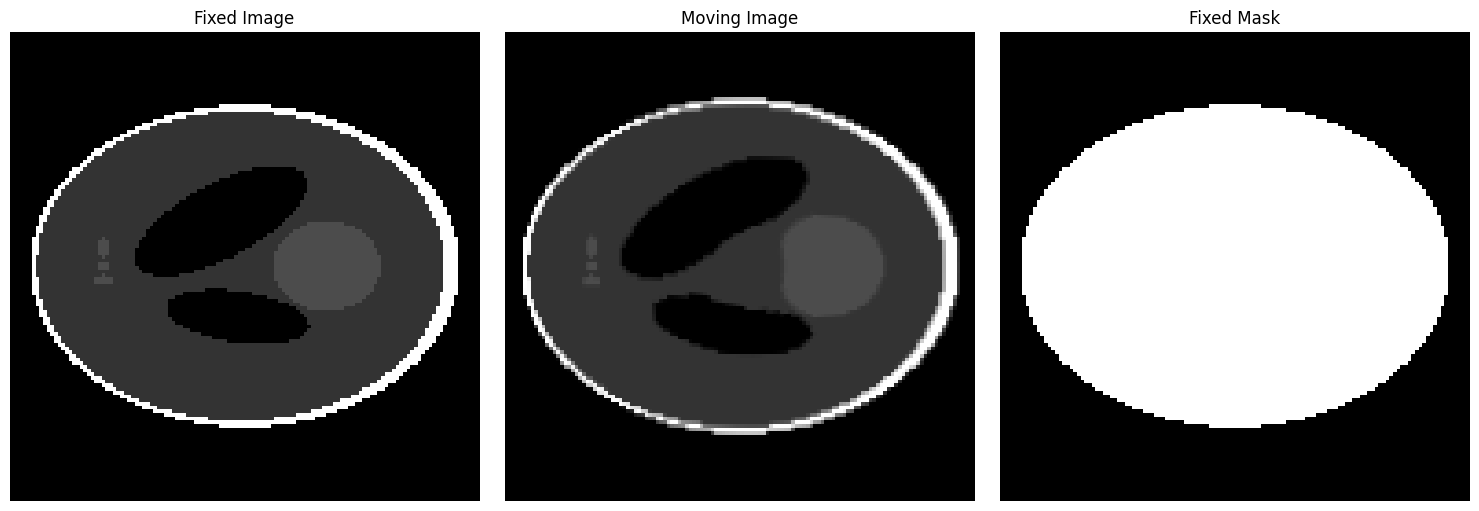

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fixed_np = itk.GetArrayFromImage(fixed_image)
moving_np = itk.GetArrayFromImage(moving_image)
mask_np = itk.GetArrayFromImage(fixed_mask)

slice_idx = fixed_np.shape[0] // 2

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(fixed_np[slice_idx], cmap="gray")
plt.title("Fixed Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(moving_np[slice_idx], cmap="gray")
plt.title("Moving Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_np[slice_idx], cmap="gray")
plt.title("Fixed Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

The images represent the same anatomy at two different respiratory positions.

Observe how structures shift between the fixed and moving images. These differences represent the respiratory motion that we wish to estimate through image registration.

The mask identifies the region of interest that will be used during the registration process. Restricting registration to relevant anatomy can improve both registration accuracy and computational efficiency.

Before continuing, consider the following questions:

- What regions of the brain phantom appear to be deformed?
- Do you think a rigid transformation alone would adequately align the images?

In the next step, we will create a colour overlay of the fixed and moving images to better visualise their initial misalignment.

# Step 5: Assess Alignment Before Registration

## Purpose

Before performing registration, it is useful to establish a visual baseline that can later be compared with the registration result.

One of the simplest methods for assessing image alignment is a colour overlay. In the figure below:

- The fixed image will be displayed in **green**.
- The moving image will be displayed in **red**.

Regions where the images overlap well will appear yellow because the red and green colour channels combine.

This visualisation provides an intuitive way to assess registration quality both before and after registration.

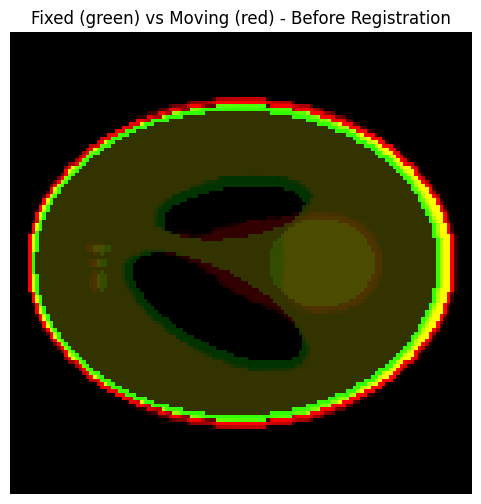

In [6]:
fixed_slice = fixed_np[slice_idx]
moving_slice = moving_np[slice_idx]

overlay_before = np.zeros((*fixed_slice.shape, 3))

overlay_before[..., 1] = fixed_slice   # green
overlay_before[..., 0] = moving_slice  # red

plt.figure(figsize=(6, 6))
plt.imshow(overlay_before, origin="lower")
plt.title("Fixed (green) vs Moving (red) - Before Registration")
plt.axis("off")
plt.show()

## Discussion

Areas appearing predominantly red or green indicate disagreement between the two respiratory states, while yellow regions indicate alignment.

Because respiratory motion causes anatomical structures to occupy different positions, substantial disagreement is expected before registration.

Keep this overlay in mind, as we will generate the same visualisation after registration and compare the two results.

In the next step, we will perform an initial registration using rigid and affine transformations to correct large-scale differences between the images.

# Step 6: Perform Initial Registration Using Rigid and Affine Transforms

## Purpose

Registration is often performed in stages, beginning with simple transformations before progressing to more complex deformable models.

In this step, we will perform:

1. **Rigid registration**
2. **Affine registration**

### Rigid Registration

Rigid registration allows:

- Translation
- Rotation

This stage corrects large-scale differences in position and orientation.

### Affine Registration

Affine registration additionally allows:

- Scaling
- Shearing

This provides a more accurate global alignment and serves as an

In [7]:
# Create a parameter object for the initial registration

param_stage1 = itk.ParameterObject.New()

param_stage1.AddParameterMap(
    itk.ParameterObject.GetDefaultParameterMap("rigid")
)

param_stage1.AddParameterMap(
    itk.ParameterObject.GetDefaultParameterMap("affine")
)

import os
os.makedirs("exampleoutput1", exist_ok=True)

# Perform rigid + affine registration

result1, transform1 = itk.elastix_registration_method(
    fixed_image,
    moving_image,
    parameter_object=param_stage1,
    output_directory="exampleoutput1/",
)

## Discussion

The registration performed in this step estimates a global transformation between the two respiratory states.

Although rigid and affine registration often improve image alignment substantially, they cannot model local anatomical motion. During respiration, different regions may deform by different amounts, meaning that a more flexible transformation model is required.

The transformation calculated here will therefore be used as the starting point for the deformable registration stage.

In the next step, we will configure a B-spline deformable registration model and explore the parameters that control its behaviour.

# Step 7: Configure the Deformable Registration

## Purpose

Rigid and affine registration improve global alignment, but they cannot model local respiratory motion.

To estimate tissue deformation, we require a more flexible transformation model. In this tutorial, we will use a **B-spline deformable registration**, which allows different regions of the image to move independently.

The behaviour of the registration is controlled through a number of parameters that determine:

- How image similarity is measured.
- How flexible the deformation can be.
- How strongly unrealistic deformations are penalised.
- How the optimisation process is performed.

Understanding these parameters is an important step towards developing robust registration workflows.

In [8]:
# Create a parameter object for deformable registration

param_stage2 = itk.ParameterObject.New()

# Default B-spline parameter map

bspline = itk.ParameterObject.GetDefaultParameterMap(
    "bspline"
)

# Similarity metric

bspline["Metric"] = [
    "AdvancedMattesMutualInformation",
    "TransformBendingEnergyPenalty"
]

bspline["Metric0Weight"] = ["1.0"]
bspline["Metric1Weight"] = ["1.0"]

# B-spline grid spacing

bspline["FinalGridSpacingInPhysicalUnits"] = ["10.0"]

# Multi-resolution registration

bspline["NumberOfResolutions"] = ["4"]

# Optimisation settings

bspline["MaximumNumberOfIterations"] = ["250"]

bspline["NumberOfSpatialSamples"] = ["5000"]

bspline["NewSamplesEveryIteration"] = ["true"]

# Sampling strategy

bspline["ImageSampler"] = ["RandomCoordinate"]

bspline["MaximumNumberOfSamplingAttempts"] = ["3"]

# Prevent sample count failures

bspline["CheckNumberOfSamples"] = ["false"]

# Initialisation

bspline["AutomaticTransformInitialization"] = [
    "true"
]

bspline["AutomaticTransformInitializationMethod"] = [
    "CenterOfGravity"
]

param_stage2.AddParameterMap(bspline)

## Understanding the Registration Parameters

### Similarity Metric

The registration metric determines how Elastix measures alignment quality.

In this tutorial we use:

- **AdvancedMattesMutualInformation**
- **TransformBendingEnergyPenalty**

Mutual Information encourages the images to become more similar, while the Bending Energy Penalty discourages unrealistic deformations.

### Bending Energy Penalty

A deformable registration can often improve image similarity by producing highly distorted transformations.

The Bending Energy Penalty acts as a regularisation term that favours smooth motion fields and reduces the likelihood of unrealistic local distortions.

### B-spline Grid Spacing

The parameter:


FinalGridSpacingInPhysicalUnits


controls the flexibility of the deformation model.

- Larger values produce smoother, more global deformations.
- Smaller values allow more local deformation.

A very flexible model may fit small image features more closely but can also introduce unrealistic behaviour.

### Multi-resolution Registration

The registration is performed at multiple image resolutions.

The optimisation first estimates motion at a coarse scale before progressively refining the transformation using finer image detail. This typically improves robustness and convergence.

### Optimisation Settings

The maximum number of iterations and spatial samples control how thoroughly the parameter space is explored.

Increasing these values may improve registration quality but will also increase computation time.

In [9]:
import os

os.makedirs("exampleoutput2", exist_ok=True)

result_image, result_transform_parameters = (
    itk.elastix_registration_method(
        fixed_image,
        moving_image,
        parameter_object=param_stage2,
        initial_transform_parameter_object=transform1,
        fixed_mask=fixed_mask,
        moving_mask=moving_mask,
        output_directory="exampleoutput2/",
        log_to_console=False
    )
)

## Discussion

The registration process may take several minutes depending on the available computational resources.

During optimisation, Elastix attempts to maximise image similarity while simultaneously maintaining a smooth and physically plausible deformation field.

Once complete, we can begin assessing the quality of the resulting registration using visual and quantitative methods.

In the next section, we will compare image alignment before and after registration using colour overlays.

# Step 9: Assess Registration Performance

## Purpose

After registration, we need to determine whether image alignment has improved.

One of the simplest and most effective approaches is to compare colour overlays before and after registration.

In the figures below:

- The fixed image is displayed in **green**.
- The moving or registered image is displayed in **red**.

Regions that overlap well will appear yellow.

In [10]:
def get_slice_np(arr):
    return arr[arr.shape[0] // 2, :, :]

def normalise(img):
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (1, 99))
    img = (img - p1) / (p99 - p1 + 1e-8)
    return np.clip(img, 0, 1)

fixed_np = itk.GetArrayFromImage(fixed_image)
moving_np = itk.GetArrayFromImage(moving_image)
result_np = itk.GetArrayFromImage(result_image)

fixed_slice = normalise(get_slice_np(fixed_np))
moving_slice = normalise(get_slice_np(moving_np))
result_slice = normalise(get_slice_np(result_np))

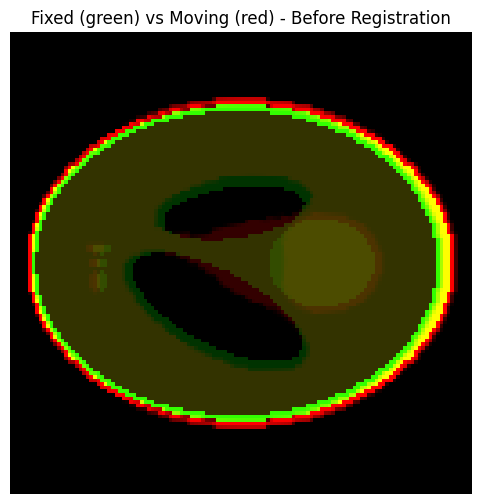

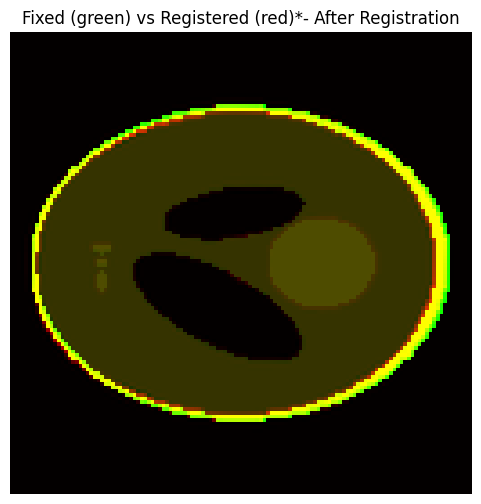

In [13]:
overlay_before = np.zeros((*fixed_slice.shape, 3))

overlay_before[..., 1] = fixed_slice
overlay_before[..., 0] = moving_slice

plt.figure(figsize=(6,6))
plt.imshow(overlay_before, origin="lower")
plt.title("Fixed (green) vs Moving (red) - Before Registration")
plt.axis("off")
plt.show()

overlay_after = np.zeros((*fixed_slice.shape, 3))

overlay_after[..., 1] = fixed_slice
overlay_after[..., 0] = result_slice
plt.figure(figsize=(6,6))
plt.imshow(overlay_after, origin="lower")
plt.title("Fixed (green) vs Registered (red)*- After Registration")
plt.axis("off")
plt.show()

## Discussion

Compare the two overlays.

A successful registration should produce:
- Increased overlap between structures.
- More yellow regions.
- Reduced red and green boundaries.
- Improved alignment of anatomical features.

Visual assessment remains one of the most important methods for evaluating registration quality and should always accompany quantitative metrics.

In the next section, we will visualise the deformation itself using a warped grip.

# Step 10: Visualise the Deformation Using a Warped Grid

## Purpose

Image overlays allow us to assess whether registration has improved image alignment, but they do not directly show how the image has been deformed.

A common way to visualise the transformation itself is to apply the deformation field to a regular grid. Regions experiencing little motion remain relatively unchanged, while regions experiencing larger motion produce visible distortions in the grid.

This provides an intuitive representation of how the registration algorithm warps space in order to align the moving image with the fixed image.


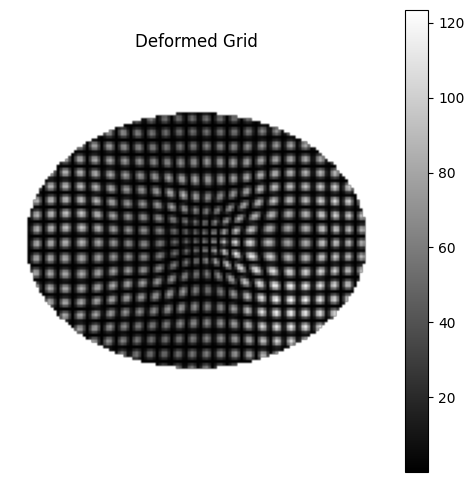

In [15]:
ImageType = type(fixed_image)

grid = itk.GridImageSource[ImageType].New()

grid.SetSpacing(fixed_image.GetSpacing())
grid.SetOrigin(fixed_image.GetOrigin())
grid.SetSize(
    fixed_image.GetLargestPossibleRegion().GetSize()
)

grid.SetGridSpacing((5.0, 5.0, 5.0))
grid.SetSigma((1.0, 1.0, 1.0))

grid.Update()

warped_grid = itk.transformix_filter(
    grid.GetOutput(),
    result_transform_parameters
)

grid_np = itk.GetArrayFromImage(warped_grid)

grid_slice = get_slice_np(grid_np)

mask_slice = get_slice_np(
    itk.GetArrayFromImage(fixed_mask)
)

grid_masked = np.where(
    mask_slice > 0,
    grid_slice,
    np.nan
)

plt.figure(figsize=(6,6))
plt.imshow(
    grid_masked,
    cmap="gray",
    origin="lower"
)

plt.title("Deformed Grid")
plt.axis("off")
plt.colorbar()

plt.show()



## Discussion

The deformation grid provides a visual representation of the estimated motion field.

Notice how originally straight grid lines become distorted within the region of interest. These distortions reflect the local transformations required to align the moving image with the fixed image.

Questions to consider:

- Which regions show the largest deformation?
- Are the distortions smooth and physically plausible?
- Do any regions show sudden or unrealistic changes?

Visual inspection of deformation grids is a useful quality-control step because unrealistic warping often becomes obvious long before it appears in quantitative metrics.

In the next section, we will calculate the Jacobian determinant, which provides a quantitative measure of local expansion and contraction induced by the deformation.

# Step 11: Calculate the Jacobian Determinant

## Purpose

The deformation field describes how individual voxels move between respiratory states. However, we may also wish to quantify how the deformation affects local volume.

This can be achieved using the Jacobian determinant.

The Jacobian determinant provides information about local expansion and contraction induced by the transformation:

- A value of 1 indicates no local volume change.
- A value greater than 1 indicates local expansion.
- A value less than 1 indicates local contraction.
- A value less than 0 indicates folding, where the transformation becomes physically implausible.

In respiratory imaging, Jacobian maps are often used as surrogate measures of regional ventilation because they quantify local tissue expansion and contraction

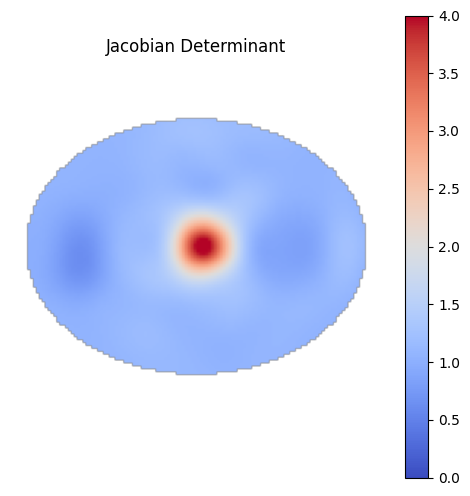

In [17]:
jacobians = itk.transformix_jacobian(
    moving_image,
    result_transform_parameters
)

detJ = np.asarray(
    jacobians[1]
).astype(np.float32)

det_slice = get_slice_np(detJ)

det_masked = np.where(
    mask_slice > 0,
    det_slice,
    np.nan
)

plt.figure(figsize=(6,6))

plt.imshow(
    det_masked,
    cmap="coolwarm",
    origin="lower",
    vmin=0,
    vmax=4
)

plt.title("Jacobian Determinant")
plt.axis("off")
plt.colorbar()

plt.show()


## Discussion

The Jacobian determinant provides a quantitative description of local deformation.

Regions with values:

- Greater than 1 indicate local expansion.
- Less than 1 indicate local contraction.
- Close to 1 indicate relatively little volume change.

As you inspect the image, consider whether the observed patterns are consistent with the respiratory motion visible in the original images.

The Jacobian determinant provides useful information about local mechanics, but it is also important to ensure that the transformation remains physically plausible. One way to assess this is by looking for regions where the Jacobian determinant becomes negative.

In the next section, we will identify and visualise any folding within the transformation.

# Step 12: Detect Folding in the Transformation

## Purpose

A realistic deformation should preserve the topology of the anatomy being registered.

One indication of an unrealistic transformation is the presence of folding. Folding occurs when the transformation effectively folds space over itself, resulting in a negative Jacobian determinant.

Negative Jacobian values are generally considered non-physical and may indicate:

- Excessive deformation
- Insufficient regularisation
- Registration failure

In this step, we will identify and visualise regions where folding occurs.

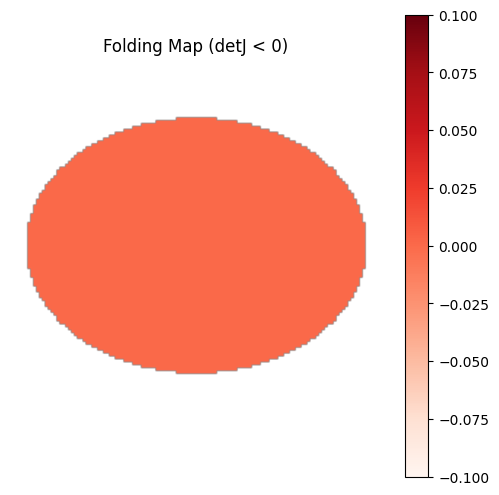

Total folding voxels: 0
Folding voxels inside mask: 0


In [19]:
folds = det_slice < 0

folds_masked = np.where(
    mask_slice > 0,
    folds,
    np.nan
)

plt.figure(figsize=(6,6))

plt.imshow(
    folds_masked,
    cmap="Reds",
    origin="lower"
)

plt.title("Folding Map (detJ < 0)")
plt.axis("off")
plt.colorbar()

plt.show()

print(
    "Total folding voxels:",
    np.sum(detJ < 0)
)

print(
    "Folding voxels inside mask:",
    np.sum((detJ < 0) & (itk.GetArrayFromImage(fixed_mask) > 0))
)

## Discussion

Ideally, the transformation should contain no folding voxels.

For this phantom dataset, a successful registration should produce a smooth deformation field with very few or no negative Jacobian values.

If large numbers of folding voxels are present, possible causes include:

- A deformation model that is too flexible.
- Insufficient regularisation.
- Poor initial alignment.
- Failure of the optimisation process.

A folding analysis provides an important quality-control measure and should  be considered when interpreting deformation fields derived from image registration.

In the next section, we will directly visualise the deformation field itself using displacement vectors.

# Step 13: Visualise the Displacement Field

## Purpose

The deformation field estimated by the registration contains a displacement vector at every voxel within the image.

Each vector describes:

- The direction of motion.
- The magnitude of motion.

Visualising these vectors provides a direct representation of the respiratory motion estimated by the registration algorithm.

To make the figure easier to interpret, we will display only a subset of the displacement vectors.

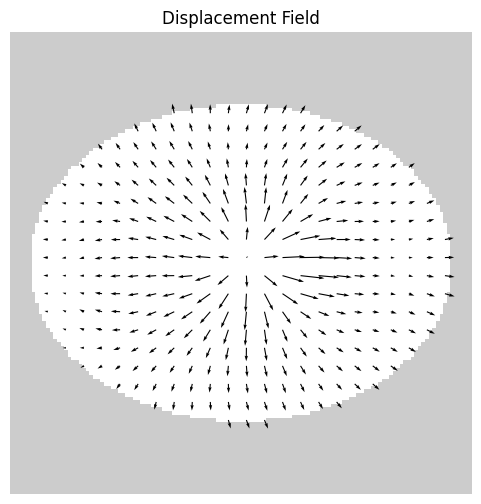

In [20]:
disp = itk.transformix_deformation_field(
    moving_image,
    result_transform_parameters
)

disp_np = itk.GetArrayFromImage(disp)

dx = get_slice_np(disp_np[..., 0])
dy = get_slice_np(disp_np[..., 1])

step = 5

X, Y = np.meshgrid(
    np.arange(0, dx.shape[1], step),
    np.arange(0, dx.shape[0], step)
)

U = dx[::step, ::step]
V = dy[::step, ::step]

M = mask_slice[::step, ::step]

U = np.where(M > 0, U, np.nan)
V = np.where(M > 0, V, np.nan)

plt.figure(figsize=(6,6))

plt.imshow(
    mask_slice,
    cmap="gray",
    alpha=0.2,
    origin="lower"
)

plt.quiver(X, Y, U, V)

plt.title("Displacement Field")
plt.axis("off")

plt.show()


## Discussion

Each arrow represents the estimated motion of a region of tissue between the moving and fixed respiratory states.

The:

- Direction of the arrow indicates the direction of motion.
- Length of the arrow indicates the magnitude of motion.

This displacement field is one of the primary outputs of deformable image registration and forms the basis of many motion analysis techniques.

Although the vector field provides detailed information, it can sometimes be difficult to interpret visually. A useful alternative is to compute the displacement magnitude, which summarises the overall amount of motion at each voxel.


# Step 14: Calculate Displacement Magnitude

## Purpose

The displacement field contains a vector describing the motion of every voxel. While this provides detailed information, it can be difficult to interpret visually.

A common alternative is to calculate the displacement magnitude, which combines the displacement components into a single value representing the overall amount of motion at each voxel.

Regions with larger values correspond to areas experiencing greater respiratory motion.

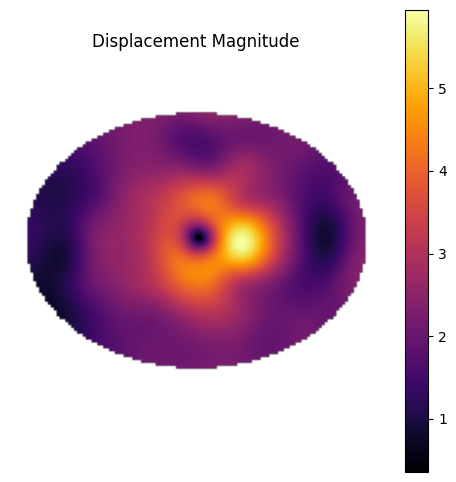

In [21]:
mag = np.sqrt(dx**2 + dy**2)

mag_masked = np.where(
    mask_slice > 0,
    mag,
    np.nan
)

plt.figure(figsize=(6,6))

plt.imshow(
    mag_masked,
    cmap="inferno",
    origin="lower"
)

plt.title("Displacement Magnitude")
plt.axis("off")
plt.colorbar()

plt.show()


## Discussion

The displacement magnitude map provides a simple summary of respiratory motion throughout the image.

Areas with larger values correspond to regions undergoing greater displacement between the fixed and moving respiratory states.

Consider the following questions:

- Which regions show the greatest motion?
- Do these regions correspond to areas where the deformation grid was most distorted?
- Are the motion patterns consistent with the original image differences observed at the start of the tutorial?

Displacement magnitude maps are widely used for motion analysis and provide a useful complement to Jacobian-based measures of local expansion and contraction.


# Reflection

Throughout this tutorial we explored several transformation models:

- Rigid
- Affine
- B-spline deformable

A key lesson from image registration is that the most complex model is not always the most appropriate.

When selecting a registration strategy, consider:

- What motion is expected?
- Is deformation physically plausible?
- Does a more flexible model provide meaningful improvement?
- Are there signs of unrealistic behaviour such as folding?

Successful image registration requires not only a good algorithm, but also an understanding of the underlying anatomy, physiology and imaging physics.

The objective of this tutorial was to provide example code needed to get started with Elastix. The Elastix GitHub page contains links to multiple notebook tutorials:

https://github.com/SuperElastix/elastix


# Optional Step 15: Save the Registration Results

In [ ]:
itk.imwrite(
    result_image,
    "registered_image.nii.gz"
)

# Optional Step 16: Explore Registration Parameters

Image registration often requires parameter tuning.

Try modifying one parameter at a time and evaluate how the registration result changes.

Suggested parameters:

- FinalGridSpacingInPhysicalUnits
- MaximumNumberOfIterations
- NumberOfResolutions
- Metric1Weight

After each modification, inspect:

- The image overlays
- The deformation grid
- The Jacobian determinant map
- The number of folding voxels

Can you improve the registration while maintaining a physically plausible deformation?

# Optional Challenge: Register the Experimental Phantom Data

## Background

Throughout this tutorial we have worked with a digital breathing brain phantom that contains deformation. Deformable registration was therefore required to accurately align the moving and fixed images.

We will now consider a different registration problem.

The experimental phantom images were created at the end of tutorial:

https://github.com/nicholas-senn/teaching-resources/tree/main/lung-MRI/Advanced-Chest-MRI-School-2026/Image%20Reconstruction%20and%20Motion%20Gating

Imaging data was from a physical phantom undergoing rigid motion. Unlike the digital breathing phantom, these images do not contain anatomical deformation. Instead, the differences between the images are primarily due to changes in position and orientation.

In practice, selecting an appropriate transformation model is an important part of any registration workflow. Using an overly flexible model can introduce unrealistic distortions and reduce the physical interpretability of the results.

Now, the challenge is to successfully register the experimental phantom images and determine which registration strategy produces the most appropriate result.

It will not be easy because the images contian differences in blurring and distortion. The object may have also displaced outside the region that can be imaged. It might be useful to create and use masks so that only some parts of the images are used for the registration. Disclaimer: I have not attempted to register these images.

In [23]:
download_file(
    "https://github.com/nicholas-senn/teaching-resources/releases/download/v1.0/fixed_image_A_phantom.nii.gz",
    "fixed_phantom_image.nii.gz"
)

download_file(
    "https://github.com/nicholas-senn/teaching-resources/releases/download/v1.0/moving_image_A_phantom.nii.gz",
    "moving_phantom_image.nii.gz"
)


fixed_image_phantom = itk.imread(
    "fixed_phantom_image.nii.gz",
    itk.F
)

moving_image_phantom = itk.imread(
    "moving_phantom_image.nii.gz",
    itk.F
)



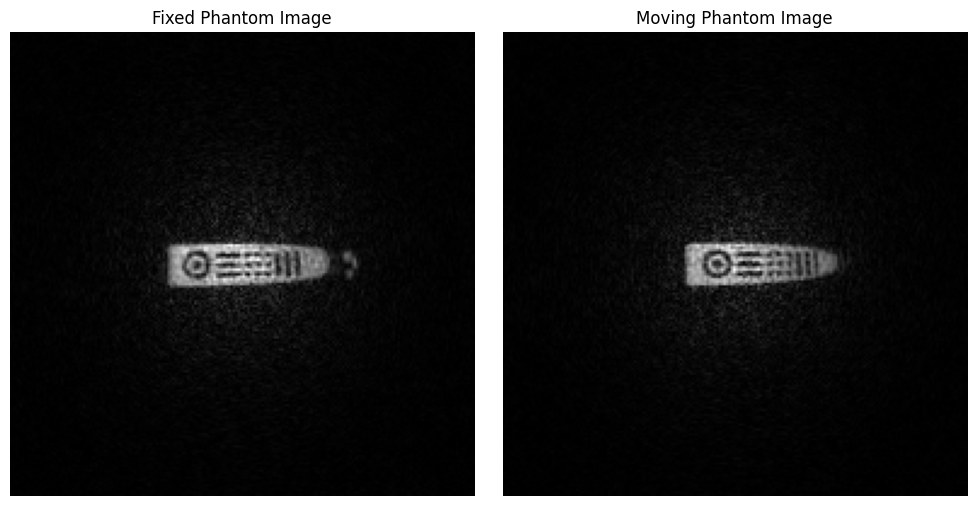

In [26]:
fixed_np = itk.GetArrayFromImage(fixed_image_phantom)
moving_np = itk.GetArrayFromImage(moving_image_phantom)

slice_idx = (fixed_np.shape[1] // 2) + 5

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    fixed_np[:, slice_idx, :],
    cmap="gray",
    origin="lower"
)
plt.title("Fixed Phantom Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    moving_np[:, slice_idx, :],
    cmap="gray",
    origin="lower"
)
plt.title("Moving Phantom Image")
plt.axis("off")

plt.tight_layout()
plt.show()